### ReAct Agent

- LangSmith
- Tools - out of the box
- Tools - custom
- Checkpointing
- Memory

In [1]:
# Import necessary libraries
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI

In [2]:
# Load environment variables from .env file
load_dotenv(override=True)  

True

In [3]:
# Set up LangSmith

In [4]:
# Set up Google Serper API wrapper
from langchain_community.utilities import GoogleSerperAPIWrapper

/tmp/ipykernel_2371/3956194880.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


In [5]:
# Set up Google Serper API wrapper
serper = GoogleSerperAPIWrapper()
serper.run("What is the largest desert in the world?")


"This article provides a list of deserts ranked by the total area. Only deserts greater than 50,000 km 2 (19,300 sq mi) are included in this ranking. The Antarctic Polar Desert, which makes up the vast majority of Antarctica, is the largest desert in the world. Simply Sayo Debates Nicki Minaj Vs Megan, Valentine Posts & Embarrassing Voice Notes. WHAT IS THE LARGEST DESERT IN THE WORLD? 297K. Dislike. The largest desert on Earth is Antarctica, which covers 14.2 million square kilometers (5.5 million square miles). It is also the coldest desert ... TIL that the the world's largest desert is not the Sahara; it's actually Antarctica, as deserts are defined by their low precipitation, not just ... The rest of Earth's deserts are outside of the polar areas. The largest is the Sahara Desert, a subtropical desert in northern Africa. It covers a surface area ... Covered in dunes and the occasional palm tree, the Sahara is what we might traditionally think of as a desert – the entire 9.4 million

In [6]:
# Define a tool that uses the Serper API wrapper to search the web for information
from langchain_core.tools import tool

@tool
def search(query: str) -> str:
    """Search the web for information."""
    return serper.run(query)

In [7]:
# Let's try out the tool we just defined by invoking it with a query
search.invoke("What is the largest desert in the world?")

"This article provides a list of deserts ranked by the total area that they cover on Earth. Only deserts greater than 50,000 km 2 (19,300 sq mi) are included ... Simply Sayo Debates Nicki Minaj Vs Megan, Valentine Posts & Embarrassing Voice Notes. WHAT IS THE LARGEST DESERT IN THE WORLD? 297K. Dislike. The Antarctic Polar Desert, which makes up the vast majority of Antarctica, is the largest desert in the world. In fact, this single desert is larger than the ... TIL that the the world's largest desert is not the Sahara; it's actually Antarctica, as deserts are defined by their low precipitation, not just ... The largest desert on Earth is Antarctica, which covers 14.2 million square kilometers (5.5 million square miles). It is also the coldest desert ... The largest desert in the world is not. Believe it or not, the largest desert instead is filled with ice and penguins. Antarctica is covered in 5.5 million ... Covered in dunes and the occasional palm tree, the Sahara is what we might 

In [8]:
# Set up SendGrid API credentials
from sendgrid import SendGridAPIClient
from sendgrid.helpers.mail import Mail

sendgrid_api_key = os.getenv("SENDGRID_API_KEY")
sendgrid_from_email = os.getenv("SENDGRID_FROM_EMAIL")
sendgrid_to_email = os.getenv("SENDGRID_TO_EMAIL")

In [9]:
# Define a tool that uses the SendGrid API to send email notifications
@tool
def notify(message: str) -> str:
    """Send an email notification to the user via SendGrid."""
    try:
        mail = Mail(
            from_email=sendgrid_from_email,
            to_emails=sendgrid_to_email,
            subject="Agent Notification",
            plain_text_content=message
        )
        sg = SendGridAPIClient(sendgrid_api_key)
        response = sg.send(mail)
        return f"Email sent successfully! Status: {response.status_code}"
    except Exception as e:
        return f"Failed to send email: {str(e)}"

In [10]:
notify.invoke("This is a test notification from the agent.")

'Email sent successfully! Status: 202'

In [11]:
# bundling both tools into a list to pass to the LLM and ToolNode
tools = [search, notify]

In [12]:
# MemorySaver adds persistent memory to your agent via checkpointing
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [13]:
# Back to Graph
# Define the state object
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [14]:
# Start the Graph Builder with this State class
graph_builder = StateGraph(State)

In [15]:
# Initialize the LLM and bind the tools to it
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [16]:
# Create a Node
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [17]:
# Create Edges
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

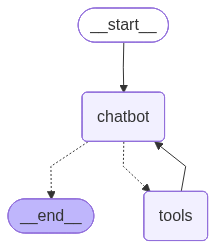

In [18]:
# Compile the graph and visualize it
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
# This config object is passed to graph.invoke() to enable thread-based memory via the MemorySaver checkpointer
config = {"configurable": {"thread_id": "1"}}

In [20]:
# Chat function
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content

gr.ChatInterface(chat).launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://5c636b30b297f346d6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
# Get the current state of the graph
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='1e70f0b3-a79b-4ca8-b995-a5d6e4a2c84f'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 67, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3fb44b05a1', 'id': 'chatcmpl-Dr75mngje1y51lRT4WP9xFW9pmI6v', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eccb7-2ca8-7612-967d-dd0ce96a0513-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 67, 'output_tokens': 10, 'total_tokens': 77, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [22]:
# Let's convert the StateSnapshot object into a list to make it easier to inspect its contents
list(graph.get_state(config))


[{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='1e70f0b3-a79b-4ca8-b995-a5d6e4a2c84f'),
   AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 67, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3fb44b05a1', 'id': 'chatcmpl-Dr75mngje1y51lRT4WP9xFW9pmI6v', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eccb7-2ca8-7612-967d-dd0ce96a0513-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 67, 'output_tokens': 10, 'total_tokens': 77, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_detai